# Trapezoid Polarity Extension

This notebook extends the split-half trapezoid analysis across trapezoid polarity.

Panels:

1. Mean split-half grid size across short/top edge width.
2. Mean split-half grid score across short/top edge width.

This version uses top widths `0.0, 0.4, 0.8, 1.2, 1.6` for both Tr-only and Sq-Tr conditions.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.visualize import compute_grid_metrics

RESULTS_DIR = PROJECT_ROOT / "results" / "tpc"
FIG_DIR = PROJECT_ROOT / "results" / "trapezoid_extension"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
RESULTS_DIR = PROJECT_ROOT / "results" / "tpc"

# Runs for the six rows
BASELINE_RUN = "Apr-10-2025-16-13-23"
SQ_TR_04_RUN = "May-28-2026-22-49-13"      # Sq -> Tr, top_width=0.4
TR_ONLY_04_RUN = "May-28-2026-00-25-00"    # Tr only, top_width=0.4
SQ_TR_00_RUN = "May-28-2026-21-39-02"      # Sq -> Tr, top_width=0.0
SQ_TR_12_RUN = "May-28-2026-23-59-16"      # Sq -> Tr, top_width=1.2
LARGE_SQ_RUN = "May-24-2026-14-35-07"      # Sq -> large square
REMAP_SQ_RUN = "Jun-10-2026-13-49-49"      # Sq -> remapped square, 50 epochs
# REMAP_SQ_RUN = "Jun-11-2026-16-22-39"    # use this after inference finishes

LONG_WIDTH = 1.6
SIZE_THRESHOLD = 0.5
SCALE_METHOD = "average"

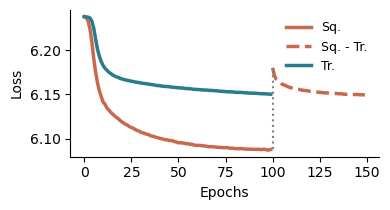

In [4]:
import os
sq_loss = np.load(os.path.join('../results/tpc', BASELINE_RUN, 'loss.npy'))
tr_loss = np.load(os.path.join('../results/tpc', TR_ONLY_04_RUN, 'loss.npy'))
sq2tr_loss = np.load(os.path.join('../results/tpc', SQ_TR_04_RUN, 'loss.npy'))
sq2tr_overall_loss = np.concatenate((sq_loss, sq2tr_loss))

colors = {
    "Sq-Tr": "#C56A4D",
    "Tr": "#287C8E",
    "Sq": "#555555"
}
fig, ax = plt.subplots(figsize=(4,2.2))
ax.spines[['right', 'top']].set_visible(False)
plt.plot(np.arange(100), sq_loss, color=colors["Sq-Tr"], label='Sq.', lw=2.5)
plt.plot(np.arange(100, 150), sq2tr_loss, color=colors["Sq-Tr"], ls='--', label='Sq. - Tr.', lw=2.5)
plt.vlines(x=100, ymin=sq_loss[-1], ymax=sq2tr_loss[0], color='gray', linestyle=':')
plt.plot(np.arange(100), tr_loss, color=colors["Tr"], label='Tr.', lw=2.5)
# plt.plot(np.arange(100, 150), tr2sq_loss, color=colors["Tr"], ls='--', label='Tr. - Sq.', lw=2)
# plt.vlines(x=100, ymin=tr_loss[-1], ymax=tr2sq_loss[0], color='gray', linestyle=':')
plt.legend(frameon=False, fontsize=9, loc='upper right')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.tight_layout()
# plt.savefig(FIG_DIR / "loss_curves.pdf", bbox_inches="tight")
plt.show()

## Trapezoid envs

Baseline top cell: 573
Tr-only 0.4 top cell: 592


C:\Users\User\AppData\Local\Temp\ipykernel_37364\3198713609.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


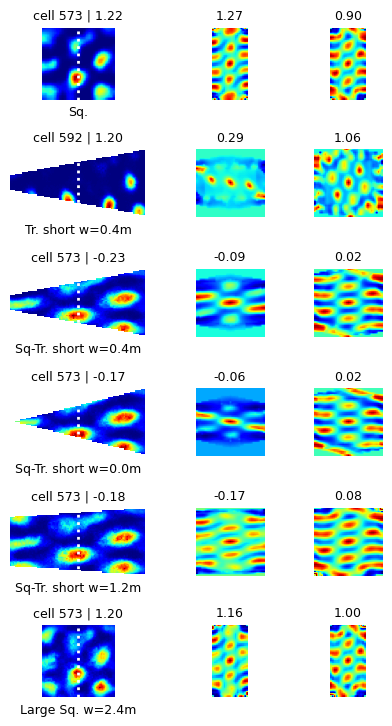

[{'cell_id': 573,
  'rank': 4,
  'full_score': 1.222114563509521,
  'display_left_score': 1.2692563962318317,
  'display_right_score': 0.8997112066343382,
  'label': 'Sq.',
  'run': 'Apr-10-2025-16-13-23'},
 {'cell_id': 592,
  'rank': 2,
  'full_score': 1.1991024439660416,
  'display_left_score': 0.28955574270917056,
  'display_right_score': 1.0552577916461936,
  'label': 'Tr. short w=0.4m',
  'run': 'May-28-2026-00-25-00'},
 {'cell_id': 573,
  'rank': 962,
  'full_score': -0.22639137669994716,
  'display_left_score': -0.09173424162366506,
  'display_right_score': 0.02113495212841239,
  'label': 'Sq-Tr. short w=0.4m',
  'run': 'May-28-2026-22-49-13'},
 {'cell_id': 573,
  'rank': 799,
  'full_score': -0.16717068144623765,
  'display_left_score': -0.05590973845351751,
  'display_right_score': 0.019975181538953793,
  'label': 'Sq-Tr. short w=0.0m',
  'run': 'May-28-2026-21-39-02'},
 {'cell_id': 573,
  'rank': 915,
  'full_score': -0.17550207837166923,
  'display_left_score': -0.1721488362

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path



def load_run_arrays(run_path):
    run_path = Path(run_path)
    unsrt_scores = np.load(run_path / "unsrt_grid_scores.npy")
    sort_idx = np.argsort(unsrt_scores)[::-1]

    arrays = {
        "run_path": run_path,
        "cfg": json.loads((run_path / "configs.json").read_text()),
        "unsrt_scores": unsrt_scores,
        "sort_idx": sort_idx,
        # grid_maps.npy is saved sorted by descending full-map grid score in current eval code.
        "grid_maps_sorted": np.load(run_path / "grid_maps.npy", allow_pickle=True),
        # left/right SACs and scores are saved in original cell-id order.
        "left_sac": np.load(run_path / "left_sac.npy", allow_pickle=True),
        "right_sac": np.load(run_path / "right_sac.npy", allow_pickle=True),
        "left_scores": np.load(run_path / "left_grid_scores.npy"),
        "right_scores": np.load(run_path / "right_grid_scores.npy"),
    }
    return arrays


def get_sorted_rank(sort_idx, cell_id):
    loc = np.where(sort_idx == int(cell_id))[0]
    if len(loc) == 0:
        raise ValueError(f"cell_id {cell_id} not found in sort_idx")
    return int(loc[0])

import matplotlib as mpl
from src.visualize import trapezoid_mask

def maybe_mask_env(rate_map, cfg, flip_lr=True):
    env_shape = cfg.get("env_shape", "rectangle")

    if env_shape != "trapezoid":
        return rate_map

    h, w = rate_map.shape
   # trapezoid_mask returns shape (res_w, res_h), so pass map dims accordingly.
    mask = trapezoid_mask(
        width=float(cfg["box_width"]),
        height=float(cfg["box_height"]),
        res_w=h,
        res_h=w,
        top_width=cfg.get("trapezoid_top_width", None),
    )

    if mask.shape != rate_map.shape:
        raise ValueError(
            f"Mask shape {mask.shape} does not match rate_map shape {rate_map.shape}"
        )


    if flip_lr:
        mask = np.fliplr(mask)

    # Assumes mask=True means valid arena. If your mask is opposite, swap ~mask -> mask.
    return np.ma.masked_where(~mask, rate_map)

def clean_image_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

def plot_example_row(
    run_path,
    axes,
    cell_id=None,
    label=None,
    rate_cmap="jet",
    sac_cmap="jet",
    show_cell_id=True,
    split_line=True,
    flip_lr=True,
    mask_non_env=True,
):
    arr = load_run_arrays(run_path)
    cfg = arr["cfg"]
    sort_idx = arr["sort_idx"]

    if cell_id is None:
        cell_id = int(sort_idx[0])

    rank = get_sorted_rank(sort_idx, cell_id)

    rate_map = arr["grid_maps_sorted"][rank]
    left_sac = arr["left_sac"][cell_id]
    right_sac = arr["right_sac"][cell_id]

    full_score = float(arr["unsrt_scores"][cell_id])
    left_score = float(arr["left_scores"][cell_id])
    right_score = float(arr["right_scores"][cell_id])

    if flip_lr:
        rate_map = np.fliplr(rate_map)

        # After visual flip, displayed-left corresponds to original-right.
        display_left_sac = np.fliplr(right_sac)
        display_right_sac = np.fliplr(left_sac)
        display_left_score = right_score
        display_right_score = left_score
    else:
        display_left_sac = left_sac
        display_right_sac = right_sac
        display_left_score = left_score
        display_right_score = right_score

    if mask_non_env:
        rate_map = maybe_mask_env(rate_map, cfg, flip_lr=flip_lr)

    rate_cmap_obj = mpl.colormaps[rate_cmap].copy()
    rate_cmap_obj.set_bad(color="white", alpha=0.0)

    ax_rm, ax_l, ax_r = axes

    ax_rm.imshow(rate_map, origin="lower", cmap=rate_cmap_obj)

    if split_line:
        ax_rm.axvline(rate_map.shape[1] / 2 - 0.5, color="white", ls=":", lw=2)

    ax_rm.set_xticks([])
    ax_rm.set_yticks([])

    if label is not None:
        ax_rm.set_xlabel(label, fontsize=9)

    if show_cell_id:
        ax_rm.set_title(f"cell {cell_id} | {full_score:.2f}", fontsize=9)
    else:
        ax_rm.set_title(f"{full_score:.2f}", fontsize=9)
    clean_image_axis(ax_rm)
    
    ax_l.imshow(display_left_sac, origin="lower", cmap=sac_cmap)
    ax_l.set_title(f"{display_left_score:.2f}", fontsize=9)
    ax_l.set_xticks([])
    ax_l.set_yticks([])
    clean_image_axis(ax_l)

    ax_r.imshow(display_right_sac, origin="lower", cmap=sac_cmap)
    ax_r.set_title(f"{display_right_score:.2f}", fontsize=9)
    ax_r.set_xticks([])
    ax_r.set_yticks([])
    clean_image_axis(ax_r)

    return {
        "cell_id": cell_id,
        "rank": rank,
        "full_score": full_score,
        "display_left_score": display_left_score,
        "display_right_score": display_right_score,
    }


# Choose tracked cells
baseline_arrays = load_run_arrays(RESULTS_DIR / BASELINE_RUN)
baseline_top_cell = int(baseline_arrays["sort_idx"][4])

tr04_arrays = load_run_arrays(RESULTS_DIR / TR_ONLY_04_RUN)
tr04_top_cell = int(tr04_arrays["sort_idx"][2])

print("Baseline top cell:", baseline_top_cell)
print("Tr-only 0.4 top cell:", tr04_top_cell)


rows = [
    {
        "label": "Sq.",
        "run": BASELINE_RUN,
        "cell_id": baseline_top_cell,
    },
    {
        "label": "Tr. short w=0.4m",
        "run": TR_ONLY_04_RUN,
        "cell_id": tr04_top_cell,
    },
    {
        "label": "Sq-Tr. short w=0.4m",
        "run": SQ_TR_04_RUN,
        "cell_id": baseline_top_cell,
    },
    {
        "label": "Sq-Tr. short w=0.0m",
        "run": SQ_TR_00_RUN,
        "cell_id": baseline_top_cell,
    },
    {
        "label": "Sq-Tr. short w=1.2m",
        "run": SQ_TR_12_RUN,
        "cell_id": baseline_top_cell,
    },
    {
        "label": "Large Sq. w=2.4m",
        "run": LARGE_SQ_RUN,
        "cell_id": baseline_top_cell,
    },
]


fig, axes = plt.subplots(
    len(rows),
    3,
    figsize=(4.8, 1.45 * len(rows)),
    gridspec_kw={"width_ratios": [2.0, 1.0, 1.0], "wspace": 0.55, "hspace": 0.65},
    squeeze=False,
)

row_infos = []
for i, row in enumerate(rows):
    info = plot_example_row(
        RESULTS_DIR / row["run"],
        axes[i],
        cell_id=row["cell_id"],
        label=row["label"],
        rate_cmap="jet",
        sac_cmap="jet",
        show_cell_id=True,
    )
    info.update(row)
    row_infos.append(info)

# axes[0, 0].set_ylabel("Rate map", fontsize=10)
# axes[0, 1].set_ylabel("Left SAC", fontsize=10)
# axes[0, 2].set_ylabel("Right SAC", fontsize=10)

plt.tight_layout()
# plt.savefig(FIG_DIR / "example_cells.pdf", bbox_inches="tight")
plt.show()

row_infos

C:\Users\User\AppData\Local\Temp\ipykernel_37364\3577208014.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


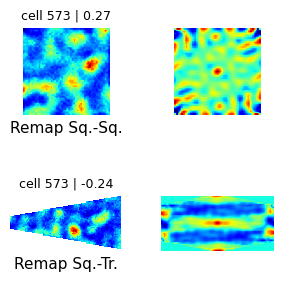

[{'label': 'Remap Sq.-Sq.',
  'cell_id': 573,
  'rank': 329,
  'score': 0.27278099912549714,
  'run': 'Jun-10-2026-13-49-49'},
 {'label': 'Remap Sq.-Tr.',
  'cell_id': 573,
  'rank': 542,
  'score': -0.24447673652276392,
  'run': 'Jun-11-2026-20-47-42'}]

In [6]:
REMAP_SQ_RUN = "Jun-10-2026-13-49-49"
REMAP_TR_RUN = "Jun-11-2026-20-47-42"

# Track the same baseline-selected cell.
# You already computed this above:
# baseline_top_cell = int(baseline_arrays["sort_idx"][4])
tracked_cell = baseline_top_cell


def plot_full_rm_sac_row(
    run_path,
    axes,
    cell_id,
    label=None,
    rate_cmap="jet",
    sac_cmap="viridis",
    flip_lr=True,
    mask_non_env=True,
):
    arr = load_run_arrays(run_path)
    cfg = arr["cfg"]

    full_sacs_sorted = np.load(Path(run_path) / "sac.npy", allow_pickle=True)

    rank = get_sorted_rank(arr["sort_idx"], cell_id)

    rate_map = arr["grid_maps_sorted"][rank]
    sac = full_sacs_sorted[rank]

    score = float(arr["unsrt_scores"][cell_id])

    if flip_lr:
        rate_map = np.fliplr(rate_map)
        sac = np.fliplr(sac)

    if mask_non_env:
        rate_map = maybe_mask_env(rate_map, cfg, flip_lr=flip_lr)

    rate_cmap_obj = mpl.colormaps[rate_cmap].copy()
    rate_cmap_obj.set_bad(color="white", alpha=0.0)

    ax_rm, ax_sac = axes

    ax_rm.imshow(rate_map, origin="lower", cmap=rate_cmap_obj)
    ax_rm.set_title(f"cell {cell_id} | {score:.2f}", fontsize=9)
    if label is not None:
        ax_rm.set_xlabel(label, fontsize=11)
    clean_image_axis(ax_rm)

    ax_sac.imshow(sac, origin="lower", cmap=sac_cmap)
    # ax_sac.set_title("SAC", fontsize=9)
    clean_image_axis(ax_sac)

    return {
        "label": label,
        "cell_id": int(cell_id),
        "rank": int(rank),
        "score": score,
    }


rows_remap = [
    {
        "label": "Remap Sq.-Sq.",
        "run": REMAP_SQ_RUN,
        "cell_id": tracked_cell,
    },
    {
        "label": "Remap Sq.-Tr.",
        "run": REMAP_TR_RUN,
        "cell_id": tracked_cell,
    },
]

fig, axes = plt.subplots(
    len(rows_remap),
    2,
    figsize=(3.4, 1.55 * len(rows_remap)),
    gridspec_kw={"width_ratios": [1.5, 1.5], "wspace": 0.35, "hspace": 0.75},
    squeeze=False,
)

remap_infos = []
for i, row in enumerate(rows_remap):
    info = plot_full_rm_sac_row(
        RESULTS_DIR / row["run"],
        axes[i],
        cell_id=row["cell_id"],
        label=row["label"],
        rate_cmap="jet",
        sac_cmap="jet",
        flip_lr=True,
        mask_non_env=True,
    )
    info.update(row)
    remap_infos.append(info)

plt.tight_layout()
# plt.savefig(FIG_DIR / "remap_example_cells.pdf", bbox_inches="tight")
plt.show()

remap_infos

In [7]:
REMAP_SCORE_RUNS = {
    "Baseline Sq.": BASELINE_RUN,
    "Remap Sq.-Sq.": "Jun-10-2026-13-49-49",
    "Remap Sq-Tr.": "Jun-11-2026-20-47-42",
}

TOP_K_SCORE = 32  # e.g. 32
rows = []

for label, run_id in REMAP_SCORE_RUNS.items():
    scores = np.load(RESULTS_DIR / run_id / "unsrt_grid_scores.npy")
    top_scores = np.sort(scores)[::-1][:TOP_K_SCORE]

    rows.append({
        "condition": label,
        "run": run_id,
        "top_k": TOP_K_SCORE,
        "top_score_mean": np.nanmean(top_scores),
        "top_score_sem": np.nanstd(top_scores, ddof=1) / np.sqrt(np.isfinite(top_scores).sum()),
        "top_score_median": np.nanmedian(top_scores),
        "max_score": np.nanmax(scores),
        "n_gt_0.8": int(np.sum(scores > 0.8)),
        "frac_gt_0.8": float(np.mean(scores > 0.8)),
    })

remap_top_score_summary = pd.DataFrame(rows)
remap_top_score_summary

,condition,run,top_k,top_score_mean,top_score_sem,top_score_median,max_score,n_gt_0.8,frac_gt_0.8
0,Baseline Sq.,Apr-10-2025-16-13-23,32,1.120480,0.015577,1.088686,1.350268,92,0.089844
1,Remap Sq.-Sq.,Jun-10-2026-13-49-49,32,0.893628,0.019297,0.906414,1.143943,23,0.022461
2,Remap Sq-Tr.,Jun-11-2026-20-47-42,32,0.148398,0.014585,0.136145,0.379534,0,0.000000


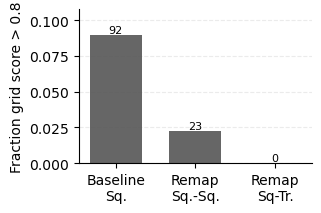

In [8]:
def plot_remap_fraction_grid_cells(threshold=0.8, save=True):
    order = ["Baseline Sq.", "Remap Sq.-Sq.", "Remap Sq-Tr."]
    colors = ["#555555", "#555555", "#555555"]

    fracs = []
    counts = []

    for label in order:
        run_id = REMAP_SCORE_RUNS[label]
        scores = np.load(RESULTS_DIR / run_id / "unsrt_grid_scores.npy")
        fracs.append(np.mean(scores > threshold))
        counts.append(int(np.sum(scores > threshold)))

    fig, ax = plt.subplots(figsize=(3, 2))
    x = np.arange(len(order))

    ax.bar(
        x,
        fracs,
        color=colors,
        width=0.65,
        edgecolor="none",
        alpha=0.9,
    )

    for xi, frac, count in zip(x, fracs, counts):
        ax.text(xi, frac, str(count), ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(["Baseline\nSq.", "Remap\nSq.-Sq.", "Remap\nSq-Tr."])
    ax.set_ylabel(f"Fraction grid score > {threshold}")
    ax.set_ylim(0, max(fracs) * 1.2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)

    # fig.tight_layout()

    if save:
        # fig.savefig(FIG_DIR / f"remapping_fraction_grid_score_gt_{threshold}.pdf", bbox_inches="tight")
        fig.savefig(FIG_DIR / f"remapping_fraction_grid_score_gt_{threshold}.png", dpi=300, bbox_inches="tight")

    return fig, ax


fig, ax = plot_remap_fraction_grid_cells(threshold=0.8)
# save the figure
# fig.savefig(FIG_DIR / f"remapping_fraction_grid_score_gt_0.8.pdf", bbox_inches="tight")

In [9]:
# Matched top-width runs currently available.
# Top width is the short edge of the trapezoid in meters.
RUNS = {
    "Tr-only": {
        0.0: "May-27-2026-22-05-46",
        0.4: "May-28-2026-00-25-00",
        0.8: "May-28-2026-01-34-38",
        1.2: "Jun-10-2026-21-15-39",
        1.6: "Jun-11-2026-00-09-49",
    },
    "Sq-Tr": {
        0.0: "May-28-2026-21-39-02",
        0.4: "May-28-2026-22-49-13",
        0.8: "May-28-2026-23-24-16",
        1.2: "May-28-2026-23-59-16",
        1.6: "Jun-11-2026-01-19-14",
    },
}

N_CELLS = 1024
SQUARE_BASELINE_RUN = "Apr-10-2025-16-13-23"

# In the original trapezoid notebook, half-map SAC metrics were converted with env_size=box_width.
# Keep that convention here for consistency with Figure 4.
HALF_SAC_ENV_SIZE = 1.6


In [10]:
def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def top_grid_cell_indices(run_id, n_cells=N_CELLS):
    """Return original cell ids of the top n_cells by full-map grid score."""
    run_dir = RESULTS_DIR / run_id
    unsrt_full_scores = np.load(require_file(run_dir / "unsrt_grid_scores.npy"))
    return np.flip(np.argsort(unsrt_full_scores))[:n_cells]


def load_run_split_half_metrics(
    run_id,
    n_cells=N_CELLS,
    cell_indices=None,
    selection_label=None,
    size_threshold=SIZE_THRESHOLD,
    scale_method=SCALE_METHOD,
    half_sac_env_size=HALF_SAC_ENV_SIZE,
):
    """
    Load saved split-half scores/SACs and compute per-cell grid size/scale metrics.

    If cell_indices is provided, those original model-cell ids are used. This is used
    for Sq-Tr transfer runs, where cells are selected by their pre-transfer square
    grid scores rather than by final trapezoid gridness.

    If cell_indices is None, top n_cells are selected by the run's own full-map grid score.
    """
    run_dir = RESULTS_DIR / run_id
    cfg = json.loads(require_file(run_dir / "configs.json").read_text())

    unsrt_full_scores = np.load(require_file(run_dir / "unsrt_grid_scores.npy"))
    if cell_indices is None:
        cell_indices = np.flip(np.argsort(unsrt_full_scores))[:n_cells]
        if selection_label is None:
            selection_label = "run_top_grid_score"
    else:
        cell_indices = np.asarray(cell_indices, dtype=int)[:n_cells]
        if selection_label is None:
            selection_label = "provided_indices"

    left_scores_all = np.load(require_file(run_dir / "left_grid_scores.npy"))
    right_scores_all = np.load(require_file(run_dir / "right_grid_scores.npy"))
    left_sacs_all = np.load(require_file(run_dir / "left_sac.npy"), allow_pickle=True)
    right_sacs_all = np.load(require_file(run_dir / "right_sac.npy"), allow_pickle=True)

    rows = []
    for rank, cell_id in enumerate(cell_indices):
        for side, scores_all, sacs_all in [
            ("Left", left_scores_all, left_sacs_all),
            ("Right", right_scores_all, right_sacs_all),
        ]:
            sac = sacs_all[cell_id]
            metrics = compute_grid_metrics(
                sac,
                env_size=half_sac_env_size,
                size_thresh_scaler=size_threshold,
                scale_method=scale_method,
            )
            rows.append({
                "run": run_id,
                "cell": int(cell_id),
                "selection_rank": int(rank),
                "selection_label": selection_label,
                "side": side,
                "grid_score": float(scores_all[cell_id]),
                "grid_scale_m": float(metrics["grid_scale_meters"]),
                "grid_size_m": float(metrics["grid_size_meters"]),
                "full_grid_score": float(unsrt_full_scores[cell_id]),
                "box_width": float(cfg["box_width"]),
                "box_height": float(cfg["box_height"]),
                "top_width": cfg.get("trapezoid_top_width", None),
                "restore": cfg.get("restore", None),
            })

    return pd.DataFrame(rows)

In [11]:
# For transfer runs, define grid cells before transfer using the original square model.
# This avoids circularly selecting cells by their final trapezoid gridness.
square_top_idx = top_grid_cell_indices(SQUARE_BASELINE_RUN, n_cells=1024)

all_rows = []
for condition, runs_by_top_width in RUNS.items():
    for top_width, run_id in runs_by_top_width.items():
        if condition == "Sq-Tr":
            df_run = load_run_split_half_metrics(
                run_id,
                n_cells=N_CELLS,
                cell_indices=square_top_idx,
                selection_label="square_baseline_top_grid_score",
            )
        else:
            df_run = load_run_split_half_metrics(
                run_id,
                n_cells=N_CELLS,
                selection_label="run_top_grid_score",
            )
        df_run["condition"] = condition
        df_run["top_width"] = float(top_width)
        all_rows.append(df_run)

cell_df = pd.concat(all_rows, ignore_index=True)
summary_df = (
    cell_df
    .groupby(["condition", "top_width", "side"], as_index=False)
    .agg(
        grid_size_mean=("grid_size_m", "mean"),
        grid_size_sem=("grid_size_m", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        grid_scale_mean=("grid_scale_m", "mean"),
        grid_scale_sem=("grid_scale_m", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        grid_score_mean=("grid_score", "mean"),
        grid_score_sem=("grid_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("cell", "count"),
    )
)

square_df = load_run_split_half_metrics(
    SQUARE_BASELINE_RUN,
    n_cells=1024,
    cell_indices=square_top_idx,
    selection_label="square_baseline_top_grid_score",
)
square_df["condition"] = "Square-only"
square_summary = (
    square_df
    .groupby(["side"], as_index=False)
    .agg(
        grid_size_mean=("grid_size_m", "mean"),
        grid_size_sem=("grid_size_m", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        grid_scale_mean=("grid_scale_m", "mean"),
        grid_scale_sem=("grid_scale_m", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        grid_score_mean=("grid_score", "mean"),
        grid_score_sem=("grid_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("cell", "count"),
    )
)

print("Sq-Tr cell selection uses square baseline cell ids:", square_top_idx.tolist())
display(cell_df.head())
display(summary_df)
display(square_summary)

Sq-Tr cell selection uses square baseline cell ids: [54, 886, 86, 528, 573, 846, 13, 606, 204, 27, 626, 267, 494, 882, 786, 674, 386, 387, 880, 377, 135, 393, 280, 438, 288, 917, 873, 830, 1011, 814, 231, 16, 710, 210, 789, 0, 761, 698, 321, 682, 619, 523, 176, 595, 440, 83, 371, 37, 895, 189, 555, 180, 678, 577, 84, 721, 997, 616, 809, 242, 891, 466, 279, 771, 610, 59, 50, 311, 329, 920, 838, 299, 193, 344, 556, 901, 398, 520, 31, 45, 208, 519, 3, 1021, 697, 246, 220, 675, 504, 665, 630, 955, 756, 547, 924, 360, 863, 646, 172, 1023, 327, 720, 129, 617, 192, 680, 642, 104, 111, 47, 1002, 255, 598, 423, 908, 463, 313, 683, 1010, 239, 893, 501, 549, 316, 303, 651, 538, 703, 105, 615, 167, 56, 635, 435, 879, 659, 679, 424, 103, 612, 881, 275, 985, 533, 998, 332, 490, 647, 813, 441, 918, 804, 864, 919, 845, 629, 910, 403, 507, 546, 731, 256, 319, 992, 934, 499, 1018, 473, 236, 375, 568, 711, 14, 532, 406, 285, 114, 505, 1005, 662, 807, 613, 49, 395, 563, 904, 539, 244, 859, 981, 4, 107, 10

,run,cell,selection_rank,selection_label,side,grid_score,grid_scale_m,grid_size_m,full_grid_score,box_width,box_height,top_width,restore,condition
0,May-27-2026-22-05-46,139,0,run_top_grid_score,Left,1.491002,0.319133,0.116038,1.415893,1.6,3.2,0.0,None,Tr-only
1,May-27-2026-22-05-46,139,0,run_top_grid_score,Right,0.144120,0.459059,0.116038,1.415893,1.6,3.2,0.0,None,Tr-only
2,May-27-2026-22-05-46,305,1,run_top_grid_score,Left,0.814411,0.332039,0.164103,1.300506,1.6,3.2,0.0,None,Tr-only
3,May-27-2026-22-05-46,305,1,run_top_grid_score,Right,0.009718,0.336355,0.116038,1.300506,1.6,3.2,0.0,None,Tr-only
4,May-27-2026-22-05-46,441,2,run_top_grid_score,Left,1.216404,0.346794,0.116038,1.265410,1.6,3.2,0.0,None,Tr-only


,condition,top_width,side,grid_size_mean,grid_size_sem,grid_scale_mean,grid_scale_sem,grid_score_mean,grid_score_sem,n
0,Sq-Tr,0.0,Left,0.279621,0.004828,0.461646,0.002279,0.108134,0.007042,1024
1,Sq-Tr,0.0,Right,0.451888,0.012185,0.445140,0.003189,0.008812,0.003383,1024
2,Sq-Tr,0.4,Left,0.279244,0.004620,0.464117,0.002221,0.121211,0.007129,1024
3,Sq-Tr,0.4,Right,0.392082,0.009782,0.449080,0.002944,0.010666,0.004556,1024
4,Sq-Tr,0.8,Left,0.284025,0.004536,0.466564,0.002091,0.121977,0.007308,1024
5,Sq-Tr,0.8,Right,0.357101,0.007141,0.466710,0.002503,0.044569,0.006155,1024
6,Sq-Tr,1.2,Left,0.295704,0.004271,0.472202,0.002196,0.126928,0.007281,1024
7,Sq-Tr,1.2,Right,0.315482,0.005376,0.469829,0.002213,0.113025,0.006809,1024
8,Sq-Tr,1.6,Left,0.276797,0.004442,0.452315,0.002325,0.122159,0.007172,1024
9,Sq-Tr,1.6,Right,0.286196,0.004713,0.456389,0.002358,0.135223,0.007082,1024


,side,grid_size_mean,grid_size_sem,grid_scale_mean,grid_scale_sem,grid_score_mean,grid_score_sem,n
0,Left,0.145193,0.003019,0.339904,0.001199,0.267908,0.010085,1024
1,Right,0.144453,0.002604,0.341246,0.001209,0.248356,0.010160,1024


In [12]:
# replace condition name Tr-only -> Tr, side: Left/Right -> L/R for plotting
summary_df["condition"] = summary_df["condition"].replace({"Tr-only": "Tr"})
summary_df["side"] = summary_df["side"].replace({"Left": "L", "Right": "R"})
square_summary["side"] = square_summary["side"].replace({"Left": "L", "Right": "R"})

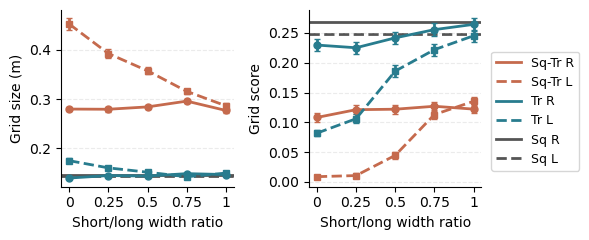

In [13]:
def plot_split_half_polarity_panels(summary_df, square_summary, save=True):
    from matplotlib.lines import Line2D

    colors = {
        "Sq-Tr": "#C56A4D",
        "Tr": "#287C8E",
    }
    square_color = "#555555"

    # The displayed trapezoid in the manuscript is flipped, so swap side labels only.
    display_side = {"L": "R", "R": "L"}

    markers = {
        "L": "o",
        "R": "s",
    }
    linestyles = {
        "L": "-",
        "R": "--",
    }

    fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharex=True)

    metric_specs = [
        ("grid_size_mean", "grid_size_sem", "Grid size (m)"),
        ("grid_score_mean", "grid_score_sem", "Grid score"),
    ]

    for ax, (mean_col, sem_col, ylabel) in zip(axes, metric_specs):
        # Square-only baselines from the run used before transfer.
        for side in ["L", "R"]:
            y = float(square_summary.loc[square_summary["side"] == side, mean_col].iloc[0])
            ax.axhline(
                y,
                color=square_color,
                linestyle=linestyles[side],
                lw=2,
                alpha=1,
                zorder=0,
            )

        for condition in ["Sq-Tr", "Tr"]:
            for side in ["L", "R"]:
                sub = summary_df[
                    (summary_df["condition"] == condition)
                    & (summary_df["side"] == side)
                ].sort_values("top_width")

                x = sub["top_width"] / LONG_WIDTH
                ax.errorbar(
                    x,
                    sub[mean_col],
                    yerr=sub[sem_col],
                    color=colors[condition],
                    marker=markers[side],
                    linestyle=linestyles[side],
                    lw=2,
                    ms=5,
                    capsize=2,
                    label="_nolegend_",
                )

        xt = np.array(sorted(summary_df["top_width"].unique())) / LONG_WIDTH
        ax.set_xlabel("Short/long width ratio")
        ax.set_ylabel(ylabel)
        ax.set_xticks(xt)
        ax.set_xticklabels([f"{v:.2g}" for v in xt])
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, linestyle="--")

    # axes[1].axhline(0, color="black", lw=0.8, ls=":", alpha=0.7)

    legend_handles = []
    for condition in ["Sq-Tr", "Tr"]:
        for side in ["L", "R"]:
            legend_handles.append(
                Line2D(
                    [0], [0],
                    color=colors[condition],
                    linestyle=linestyles[side],
                    lw=2,
                    label=f"{condition} {display_side[side]}",
                )
            )
    for side in ["L", "R"]:
        legend_handles.append(
            Line2D(
                [0], [0],
                color=square_color,
                linestyle=linestyles[side],
                lw=2,
                label=f"Sq {display_side[side]}",
            )
        )

    axes[1].legend(
        handles=legend_handles,
        frameon=True,
        fontsize=9,
        bbox_to_anchor=(1.02, 0.8),
        loc="upper left",
    )

    fig.tight_layout()

    if save:
        fig.savefig(FIG_DIR / "split_half_polarity_size_score.pdf", bbox_inches="tight")
        fig.savefig(FIG_DIR / "split_half_polarity_size_score.png", bbox_inches="tight", dpi=300)

    return fig, axes


fig, axes = plot_split_half_polarity_panels(summary_df, square_summary, save=False)
plt.show()


we try to isolate the effect of environment polarity from prior learning, by looking at a set up where the agent was initially trained in a trapezoidal environment

1. on expansion: Prior learning history produces a robust expansion of grid field size during adaptation to a polarized environment.
2. the degree of polaritization determines the symmetry. as environment becomes less polarized, the asymmetry of both size and score gradually disappears i.e. they converge
3. prior learning makes the model more vulnerable to polarity-induced disruption of gridness, especially on the left (more polarized) side of the environment.

therefore, Across a graded family of trapezoids, geometry controls the degree of grid asymmetry, while prior square training produces a robust expansion of grid field size and stronger disruption of grid regularity after transfer. Thus, grid deformation in newly encountered polarized environments is not determined by current geometry alone, but by an interaction between geometry and learning history. The model predicts that the grid deformation reported in square-to-trapezoid transfer experiments should be weaker, or qualitatively different, in animals exposed to trapezoidal environments from the beginning. Moreover, deformation should vary continuously with trapezoid polarity and should converge toward rectangular baseline values as the short edge approaches the long edge.

## Square Controls: Remapping and Size

These controls separate effects that are entangled in the square-to-trapezoid transfer experiment.

- `Sq baseline`: original 1.6 x 1.6 square used before transfer.
- `Remapped sq`: same 1.6 x 1.6 square, restored from the baseline, but with a different `place_cell_center_seed`. This isolates place-cell input-code remapping / representational novelty without changing geometry.
- `Small sq` and `Large sq`: restored from the baseline into smaller/larger square arenas. These isolate metric size change while preserving square symmetry and aspect ratio.

The default analysis below uses all recurrent units to avoid selecting cells by final gridness.

In [14]:
import json
import numpy as np
import pandas as pd
from src.visualize import compute_grid_metrics

SCRATCH_SIZE_RUNS = {
    "Small sq only": "Jun-11-2026-21-46-18",
    "Large sq only": "Jun-11-2026-22-55-34",
}

N_CELLS = 32  # change to 1024 for all cells, or e.g. 32

rows = []

for label, run_id in SCRATCH_SIZE_RUNS.items():
    run_dir = RESULTS_DIR / run_id
    cfg = json.loads((run_dir / "configs.json").read_text())

    full_scores = np.load(run_dir / "unsrt_grid_scores.npy")
    full_sacs_sorted = np.load(run_dir / "sac.npy", allow_pickle=True)

    left_scores = np.load(run_dir / "left_grid_scores.npy")
    right_scores = np.load(run_dir / "right_grid_scores.npy")
    left_sacs = np.load(run_dir / "left_sac.npy", allow_pickle=True)
    right_sacs = np.load(run_dir / "right_sac.npy", allow_pickle=True)

    sort_idx = np.argsort(full_scores)[::-1]
    selected_cells = sort_idx[:N_CELLS]
    selected_set = set(selected_cells.tolist())

    for cell_id in selected_cells:
        rank = int(np.where(sort_idx == cell_id)[0][0])

        full_metrics = compute_grid_metrics(
            full_sacs_sorted[rank],
            env_size=float(cfg["box_width"]),
            size_thresh_scaler=SIZE_THRESHOLD,
            scale_method=SCALE_METHOD,
        )

        left_metrics = compute_grid_metrics(
            left_sacs[cell_id],
            env_size=float(cfg["box_width"]),
            size_thresh_scaler=SIZE_THRESHOLD,
            scale_method=SCALE_METHOD,
        )

        right_metrics = compute_grid_metrics(
            right_sacs[cell_id],
            env_size=float(cfg["box_width"]),
            size_thresh_scaler=SIZE_THRESHOLD,
            scale_method=SCALE_METHOD,
        )

        rows.append({
            "condition": label,
            "run": run_id,
            "cell": int(cell_id),
            "box_width": float(cfg["box_width"]),
            "box_height": float(cfg["box_height"]),
            "selection": f"top_{N_CELLS}",
            "full_grid_score": float(full_scores[cell_id]),
            "full_grid_size": float(full_metrics["grid_size_meters"]),
            "left_grid_score": float(left_scores[cell_id]),
            "left_grid_size": float(left_metrics["grid_size_meters"]),
            "right_grid_score": float(right_scores[cell_id]),
            "right_grid_size": float(right_metrics["grid_size_meters"]),
        })

scratch_metric_cell_df = pd.DataFrame(rows)

scratch_metric_summary = (
    scratch_metric_cell_df
    .groupby(["condition", "run", "box_width", "box_height", "selection"], as_index=False)
    .agg(
        full_grid_score_mean=("full_grid_score", "mean"),
        full_grid_score_sem=("full_grid_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        full_grid_size_mean=("full_grid_size", "mean"),
        full_grid_size_sem=("full_grid_size", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        left_grid_score_mean=("left_grid_score", "mean"),
        left_grid_score_sem=("left_grid_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        left_grid_size_mean=("left_grid_size", "mean"),
        left_grid_size_sem=("left_grid_size", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        right_grid_score_mean=("right_grid_score", "mean"),
        right_grid_score_sem=("right_grid_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        right_grid_size_mean=("right_grid_size", "mean"),
        right_grid_size_sem=("right_grid_size", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("cell", "nunique"),
    )
)

scratch_metric_summary

,condition,run,box_width,box_height,selection,full_grid_score_mean,full_grid_score_sem,full_grid_size_mean,full_grid_size_sem,left_grid_score_mean,left_grid_score_sem,left_grid_size_mean,left_grid_size_sem,right_grid_score_mean,right_grid_score_sem,right_grid_size_mean,right_grid_size_sem,n
0,Large sq only,Jun-11-2026-22-55-34,2.4,2.4,top_32,1.055532,0.026909,0.143788,0.004497,0.471767,0.076456,0.142194,0.004433,0.659389,0.078093,0.153321,0.005979,32
1,Small sq only,Jun-11-2026-21-46-18,1.0,1.0,top_32,1.098766,0.015373,0.133222,0.004617,0.114541,0.034184,0.162732,0.011828,0.190477,0.050294,0.144771,0.006508,32


In [15]:
def build_overall_transfer_summary_baseline_tracked(n_cells=N_CELLS):
    """
    Uses full-map scores/SACs.
    For all transfer conditions, tracks the top cells selected from the baseline run.
    """
    runs = {
        "Sq baseline": "Apr-10-2025-16-13-23",
        "Small transfer": "May-24-2026-10-16-03",
        "Large transfer": "May-24-2026-14-35-07",
    }

    baseline_run = "Apr-10-2025-16-13-23"
    baseline_dir = RESULTS_DIR / baseline_run
    baseline_scores = np.load(baseline_dir / "unsrt_grid_scores.npy")
    tracked_cells = np.argsort(baseline_scores)[::-1][:n_cells]

    rows = []

    for label, run_id in runs.items():
        run_dir = RESULTS_DIR / run_id
        cfg = json.loads((run_dir / "configs.json").read_text())

        scores = np.load(run_dir / "unsrt_grid_scores.npy")
        sacs_sorted = np.load(run_dir / "sac.npy", allow_pickle=True)
        sort_idx = np.argsort(scores)[::-1]

        sizes = []
        selected_scores = []

        for cell_id in tracked_cells:
            rank = int(np.where(sort_idx == cell_id)[0][0])

            metrics = compute_grid_metrics(
                sacs_sorted[rank],
                env_size=float(cfg["box_width"]),
                size_thresh_scaler=SIZE_THRESHOLD,
                scale_method=SCALE_METHOD,
            )

            sizes.append(metrics["grid_size_meters"])
            selected_scores.append(scores[cell_id])

        rows.append({
            "condition": label,
            "run": run_id,
            "selection": f"baseline_top_{n_cells}",
            "grid_size_mean": np.nanmean(sizes),
            "grid_size_sem": np.nanstd(sizes, ddof=1) / np.sqrt(np.isfinite(sizes).sum()),
            "grid_score_mean": np.nanmean(selected_scores),
            "grid_score_sem": np.nanstd(selected_scores, ddof=1) / np.sqrt(np.isfinite(selected_scores).sum()),
            "n": len(tracked_cells),
        })

    return pd.DataFrame(rows), tracked_cells


overall_transfer_summary, tracked_cells = build_overall_transfer_summary_baseline_tracked(
    n_cells=N_CELLS
)

print("Tracked baseline cells:", tracked_cells.tolist())
overall_transfer_summary


# overall_transfer_summary = build_overall_transfer_summary(n_cells=N_CELLS)

# scratch_metric_summary already has full_grid_size_mean/full_grid_score_mean from small/big only.
overall_size_control_summary = pd.concat([
    overall_transfer_summary,
    scratch_metric_summary.assign(
        condition=scratch_metric_summary["condition"].str.replace(" sq only", " only", regex=False)
    )[[
        "condition",
        "run",
        "full_grid_size_mean",
        "full_grid_size_sem",
        "full_grid_score_mean",
        "full_grid_score_sem",
        "n",
    ]].rename(columns={
        "full_grid_size_mean": "grid_size_mean",
        "full_grid_size_sem": "grid_size_sem",
        "full_grid_score_mean": "grid_score_mean",
        "full_grid_score_sem": "grid_score_sem",
    })
], ignore_index=True)

overall_size_control_summary

Tracked baseline cells: [54, 886, 86, 528, 573, 846, 13, 606, 204, 27, 626, 267, 494, 882, 786, 674, 386, 387, 880, 377, 135, 393, 280, 438, 288, 917, 873, 830, 1011, 814, 231, 16]


,condition,run,selection,grid_size_mean,grid_size_sem,grid_score_mean,grid_score_sem,n
0,Sq baseline,Apr-10-2025-16-13-23,baseline_top_32,0.120087,0.003143,1.120480,0.015577,32
1,Small transfer,May-24-2026-10-16-03,baseline_top_32,0.116707,0.002942,0.842573,0.059760,32
2,Large transfer,May-24-2026-14-35-07,baseline_top_32,0.193897,0.006275,0.999191,0.045624,32
3,Large only,Jun-11-2026-22-55-34,NaN,0.143788,0.004497,1.055532,0.026909,32
4,Small only,Jun-11-2026-21-46-18,NaN,0.133222,0.004617,1.098766,0.015373,32


(<Figure size 600x250 with 2 Axes>,
 array([<Axes: ylabel='Grid size (m)'>, <Axes: ylabel='Grid score'>],
       dtype=object))

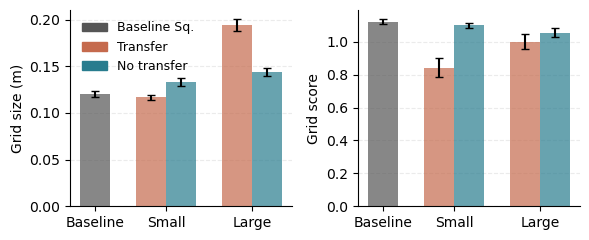

In [16]:
def plot_overall_size_controls(overall_df, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

    colors = {
        "baseline": "#555555",
        "transfer": "#c56a4d",
        "only": "#287C8E",
    }

    # Attached pairs for small and large.
    bar_width = 0.35
    x_baseline = 0.35
    x_small_transfer = 1.0
    x_small_only = x_small_transfer + bar_width
    x_large_transfer = 2.
    x_large_only = x_large_transfer + bar_width

    bar_positions = {
        "Sq baseline": x_baseline,
        "Small transfer": x_small_transfer,
        "Small only": x_small_only,
        "Large transfer": x_large_transfer,
        "Large only": x_large_only,
    }

    bar_colors = {
        "Sq baseline": colors["baseline"],
        "Small transfer": colors["transfer"],
        "Large transfer": colors["transfer"],
        "Small only": colors["only"],
        "Large only": colors["only"],
    }

    metric_specs = [
        ("grid_size_mean", "grid_size_sem", "Grid size (m)"),
        ("grid_score_mean", "grid_score_sem", "Grid score"),
    ]

    for ax, (mean_col, sem_col, ylabel) in zip(axes, metric_specs):
        for condition, xpos in bar_positions.items():
            row = overall_df[overall_df["condition"] == condition]
            mean = float(row[mean_col].iloc[0])
            sem = float(row[sem_col].iloc[0])

            ax.bar(
                xpos,
                mean,
                yerr=sem,
                width=bar_width,
                color=bar_colors[condition],
                edgecolor="none",
                capsize=3,
                alpha=0.7,
            )

        ax.set_ylabel(ylabel)
        ax.set_xticks([
            x_baseline,
            (x_small_transfer + x_small_only) / 2,
            (x_large_transfer + x_large_only) / 2,
        ])
        ax.set_xticklabels(["Baseline", "Small", "Large"])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis="y", alpha=0.25, linestyle="--")
        ax.set_axisbelow(True)

    # Simple legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors["baseline"], label="Baseline Sq."),
        plt.Rectangle((0, 0), 1, 1, color=colors["transfer"], label="Transfer"),
        plt.Rectangle((0, 0), 1, 1, color=colors["only"], label="No transfer"),
    ]
    axes[0].legend(handles=handles, frameon=False, loc="best", fontsize=9)

    fig.tight_layout()

    if save:
        fig.savefig(FIG_DIR / "square_size_controls_overall_size_score.pdf", bbox_inches="tight")
        fig.savefig(FIG_DIR / "square_size_controls_overall_size_score.png", dpi=300, bbox_inches="tight")

    return fig, axes


plot_overall_size_controls(overall_size_control_summary, save=False)

In [17]:
def build_left_right_absdiff_transfer_summary(n_cells=N_CELLS):
    """
    Tracks baseline top cells through baseline, small-transfer, and large-transfer runs.
    Computes per-cell |left - right| for grid size and grid score.
    """
    runs = {
        "Baseline": "Apr-10-2025-16-13-23",
        "Small transfer": "May-24-2026-10-16-03",
        "Large transfer": "May-24-2026-14-35-07",
    }

    baseline_run = "Apr-10-2025-16-13-23"
    baseline_scores = np.load(RESULTS_DIR / baseline_run / "unsrt_grid_scores.npy")
    tracked_cells = np.argsort(baseline_scores)[::-1][:n_cells]

    rows = []

    for label, run_id in runs.items():
        run_dir = RESULTS_DIR / run_id
        cfg = json.loads((run_dir / "configs.json").read_text())

        left_scores = np.load(run_dir / "left_grid_scores.npy")
        right_scores = np.load(run_dir / "right_grid_scores.npy")
        left_sacs = np.load(run_dir / "left_sac.npy", allow_pickle=True)
        right_sacs = np.load(run_dir / "right_sac.npy", allow_pickle=True)

        for cell_id in tracked_cells:
            left_metrics = compute_grid_metrics(
                left_sacs[cell_id],
                env_size=float(cfg["box_width"]),
                size_thresh_scaler=SIZE_THRESHOLD,
                scale_method=SCALE_METHOD,
            )
            right_metrics = compute_grid_metrics(
                right_sacs[cell_id],
                env_size=float(cfg["box_width"]),
                size_thresh_scaler=SIZE_THRESHOLD,
                scale_method=SCALE_METHOD,
            )

            rows.append({
                "condition": label,
                "run": run_id,
                "cell": int(cell_id),
                "absdiff_grid_size": abs(
                    float(left_metrics["grid_size_meters"])
                    - float(right_metrics["grid_size_meters"])
                ),
                "absdiff_grid_score": abs(
                    float(left_scores[cell_id])
                    - float(right_scores[cell_id])
                ),
            })

    diff_cell_df = pd.DataFrame(rows)

    diff_summary = (
        diff_cell_df
        .groupby(["condition", "run"], as_index=False)
        .agg(
            absdiff_grid_size_mean=("absdiff_grid_size", "mean"),
            absdiff_grid_size_sem=("absdiff_grid_size", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
            absdiff_grid_score_mean=("absdiff_grid_score", "mean"),
            absdiff_grid_score_sem=("absdiff_grid_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
            n=("cell", "nunique"),
        )
    )

    return diff_cell_df, diff_summary, tracked_cells


diff_cell_df, diff_summary, tracked_cells = build_left_right_absdiff_transfer_summary(
    n_cells=32
)

diff_summary

,condition,run,absdiff_grid_size_mean,absdiff_grid_size_sem,absdiff_grid_score_mean,absdiff_grid_score_sem,n
0,Baseline,Apr-10-2025-16-13-23,0.028901,0.006653,0.622626,0.070360,32
1,Large transfer,May-24-2026-14-35-07,0.056372,0.010240,0.616190,0.069633,32
2,Small transfer,May-24-2026-10-16-03,0.048198,0.014609,0.441828,0.060827,32


(<Figure size 150x300 with 2 Axes>,
 array([<Axes: ylabel='|L-R| size (m)'>, <Axes: ylabel='|L-R| score'>],
       dtype=object))

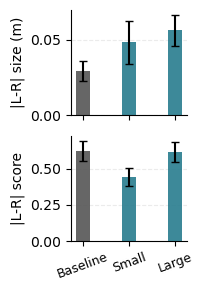

In [ ]:
def plot_left_right_absdiff_2x1(diff_summary, save=True):
    order = ["Baseline", "Small transfer", "Large transfer"]
    xticklabels = ["Baseline", "Small", "Large"]
    colors = ["#555555", "#287C8E", "#287C8E"]

    fig, axes = plt.subplots(2, 1, figsize=(1.5, 3), sharex=True)

    specs = [
        ("absdiff_grid_size_mean", "absdiff_grid_size_sem", r"|L-R| size (m)"),
        ("absdiff_grid_score_mean", "absdiff_grid_score_sem", r"|L-R| score"),
    ]

    x = np.arange(len(order))

    for ax, (mean_col, sem_col, ylabel) in zip(axes, specs):
        means, sems = [], []

        for label in order:
            row = diff_summary[diff_summary["condition"] == label]
            means.append(float(row[mean_col].iloc[0]))
            sems.append(float(row[sem_col].iloc[0]))

        ax.bar(
            x,
            means,
            yerr=sems,
            color=colors,
            width=0.3,
            edgecolor="none",
            capsize=3,
            alpha=0.9,
        )

        ax.set_ylabel(ylabel)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis="y", alpha=0.25, linestyle="--")
        ax.set_axisbelow(True)

    axes[0].set_yticks([0, 0.05])
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(xticklabels, rotation=20, ha="center", fontsize=9)

    # fig.tight_layout()

    if save:
        # fig.savefig(FIG_DIR / "square_size_transfer_left_right_absdiff.pdf", bbox_inches="tight")
        fig.savefig(FIG_DIR / "square_size_transfer_left_right_absdiff.png", dpi=300, bbox_inches="tight")

    return fig, axes


plot_left_right_absdiff_2x1(diff_summary)

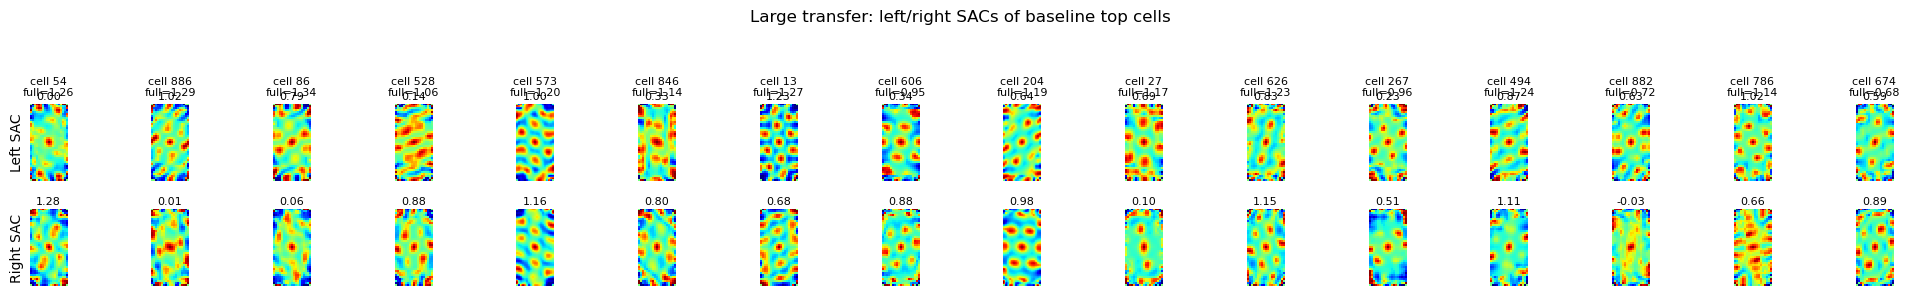

Tracked baseline cells: [54, 886, 86, 528, 573, 846, 13, 606, 204, 27, 626, 267, 494, 882, 786, 674]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

BASELINE_RUN = "Apr-10-2025-16-13-23"
LARGE_TRANSFER_RUN = "May-24-2026-14-35-07"
TOP_K = 16

# Select top cells from baseline
baseline_scores = np.load(RESULTS_DIR / BASELINE_RUN / "unsrt_grid_scores.npy")
tracked_cells = np.argsort(baseline_scores)[::-1][:TOP_K]

# Load large-transfer split-half SACs and scores
run_dir = RESULTS_DIR / LARGE_TRANSFER_RUN
left_sacs = np.load(run_dir / "left_sac.npy", allow_pickle=True)
right_sacs = np.load(run_dir / "right_sac.npy", allow_pickle=True)
left_scores = np.load(run_dir / "left_grid_scores.npy")
right_scores = np.load(run_dir / "right_grid_scores.npy")
full_scores = np.load(run_dir / "unsrt_grid_scores.npy")

fig, axes = plt.subplots(
    2,
    TOP_K,
    figsize=(1.25 * TOP_K, 2.7),
    squeeze=False,
)

for col, cell_id in enumerate(tracked_cells):
    for row, side, sacs, scores in [
        (0, "Left", left_sacs, left_scores),
        (1, "Right", right_sacs, right_scores),
    ]:
        ax = axes[row, col]
        sac = sacs[cell_id]

        vmax = np.nanpercentile(np.abs(sac), 99)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

        ax.imshow(sac, origin="lower", cmap="jet")
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        if row == 0:
            ax.set_title(
                f"cell {cell_id}\nfull={full_scores[cell_id]:.2f}",
                fontsize=8,
            )

        ax.text(
            0.5,
            1.03,
            f"{scores[cell_id]:.2f}",
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=8,
        )

axes[0, 0].set_ylabel("Left SAC", fontsize=10)
axes[1, 0].set_ylabel("Right SAC", fontsize=10)

fig.suptitle("Large transfer: left/right SACs of baseline top cells", y=1.08)
fig.tight_layout()
plt.show()

print("Tracked baseline cells:", tracked_cells.tolist())

Sq baseline Apr-10-2025-16-13-23 top cells: [54, 886, 86, 528, 573, 846, 13, 606]


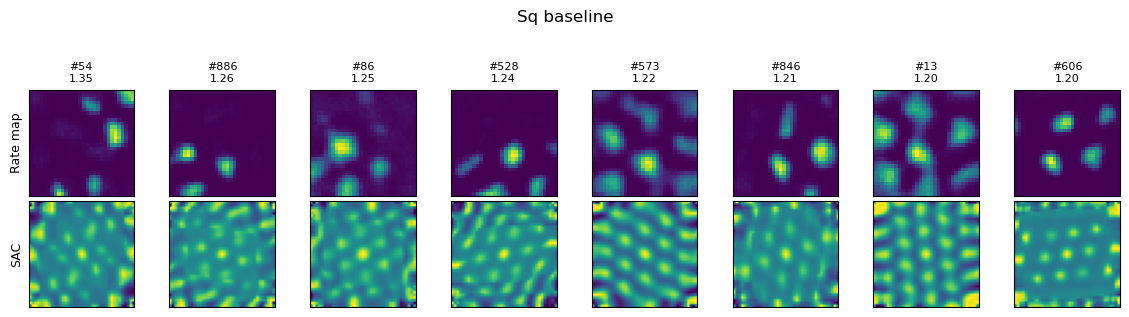

Remapped sq Jun-11-2026-16-22-39 top cells: [553, 446, 940, 1017, 931, 643, 895, 1006]


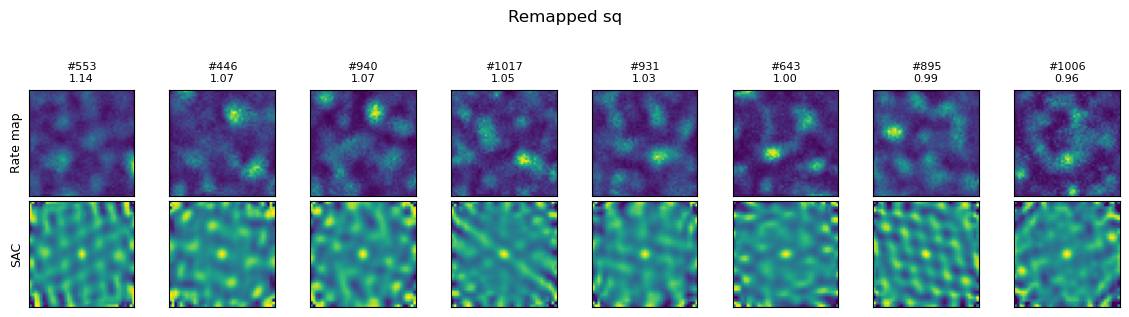

Small sq May-24-2026-10-16-03 top cells: [606, 210, 682, 494, 204, 16, 587, 280]


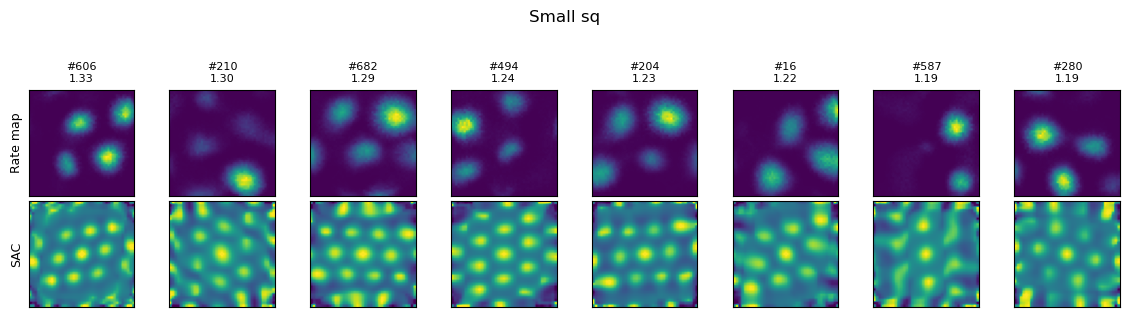

Large sq May-24-2026-14-35-07 top cells: [86, 886, 13, 54, 371, 494, 626, 104]


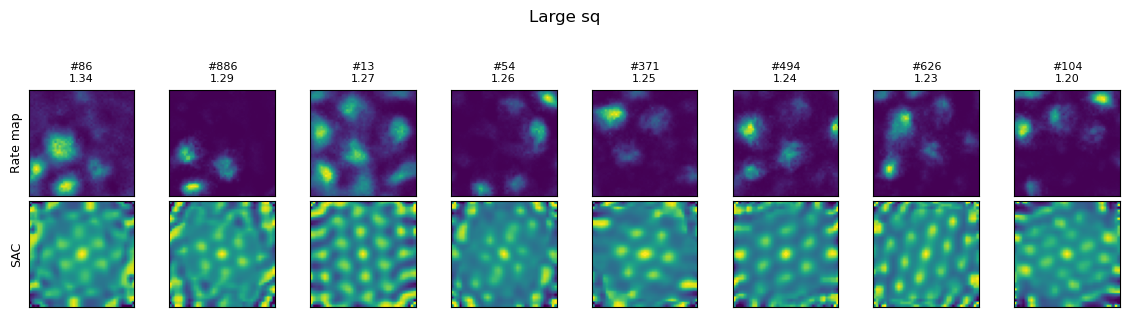

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Change these
RUN_IDS = {
    "Sq baseline": "Apr-10-2025-16-13-23",
    "Remapped sq": "Jun-11-2026-16-22-39",
    "Small sq": "May-24-2026-10-16-03",
    "Large sq": "May-24-2026-14-35-07",
}
TOP_K = 8

RESULTS_DIR = PROJECT_ROOT / "results" / "tpc"

def plot_top_grid_cells_maps_and_sac(run_id, label=None, top_k=8):
    run_dir = RESULTS_DIR / run_id

    scores = np.load(run_dir / "unsrt_grid_scores.npy")
    grid_maps = np.load(run_dir / "grid_maps.npy", allow_pickle=True)
    sacs = np.load(run_dir / "sac.npy", allow_pickle=True)

    top_idx = np.argsort(scores)[::-1][:top_k]

    fig, axes = plt.subplots(
        2, top_k,
        figsize=(1.45 * top_k, 3.0),
        squeeze=False,
    )

    for col, cell_id in enumerate(top_idx):
        rm = grid_maps[col]
        sac = sacs[col]

        ax = axes[0, col]
        ax.imshow(rm, origin="lower")
        ax.set_title(f"#{cell_id}\n{scores[cell_id]:.2f}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

        ax = axes[1, col]
        vmax = np.nanpercentile(np.abs(sac), 99)
        ax.imshow(sac, origin="lower", vmin=-vmax, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])

    axes[0, 0].set_ylabel("Rate map", fontsize=9)
    axes[1, 0].set_ylabel("SAC", fontsize=9)

    if label is None:
        label = run_id
    fig.suptitle(label, y=1.04, fontsize=12)
    fig.tight_layout()

    return fig, axes, top_idx


for label, run_id in RUN_IDS.items():
    fig, axes, top_idx = plot_top_grid_cells_maps_and_sac(
        run_id,
        label=label,
        top_k=TOP_K,
    )
    print(label, run_id, "top cells:", top_idx.tolist())
    plt.show()

Tracked baseline top cells: [54, 886, 86, 528, 573, 846, 13, 606]
Baseline scores: [1.35, 1.255, 1.255, 1.243, 1.222, 1.215, 1.203, 1.2]


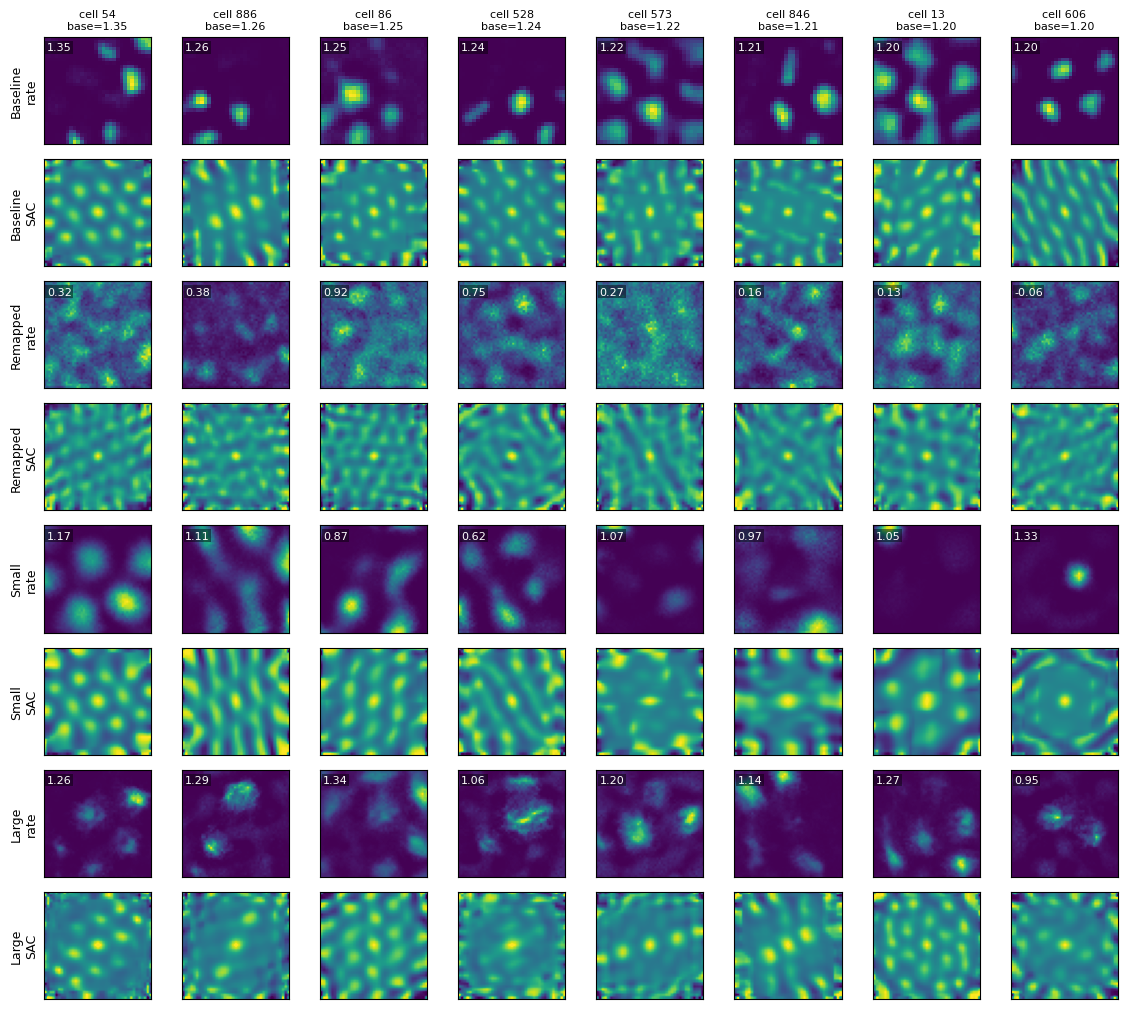

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RUNS_TRACK = {
    "Baseline": "Apr-10-2025-16-13-23",
    "Remapped": "Jun-10-2026-13-49-49",
    "Small": "May-24-2026-10-16-03",
    "Large": "May-24-2026-14-35-07",
}

TOP_K = 8
BASELINE_RUN = RUNS_TRACK["Baseline"]
RESULTS_DIR = PROJECT_ROOT / "results" / "tpc"

# Baseline maps were manually overwritten as sorted, so use the backup for original cell-id order if available.
BASELINE_MAP_FILE = "grid_maps_unsorted_backup.npy"  # fallback to grid_maps.npy if missing


def load_grid_maps_by_original_cell(run_id):
    run_dir = RESULTS_DIR / run_id

    if run_id == BASELINE_RUN and (run_dir / BASELINE_MAP_FILE).exists():
        return np.load(run_dir / BASELINE_MAP_FILE, allow_pickle=True)

    return np.load(run_dir / "grid_maps.npy", allow_pickle=True)


def load_sacs_by_original_cell(run_id):
    return np.load(RESULTS_DIR / run_id / "sac.npy", allow_pickle=True)


def load_scores_by_original_cell(run_id):
    return np.load(RESULTS_DIR / run_id / "unsrt_grid_scores.npy").reshape(-1)


# Select cells by baseline original-cell grid score.
baseline_scores = load_scores_by_original_cell(BASELINE_RUN)
tracked_cells = np.argsort(baseline_scores)[::-1][:TOP_K]

print("Tracked baseline top cells:", tracked_cells.tolist())
print("Baseline scores:", baseline_scores[tracked_cells].round(3).tolist())


def plot_tracked_cells_rate_maps_and_sacs(
    tracked_cells,
    runs=RUNS_TRACK,
    rate_cmap="viridis",
    sac_cmap="viridis",
):
    n_runs = len(runs)
    n_cells = len(tracked_cells)

    fig, axes = plt.subplots(
        2 * n_runs,
        n_cells,
        figsize=(1.45 * n_cells, 2.55 * n_runs),
        squeeze=False,
    )

    for run_i, (label, run_id) in enumerate(runs.items()):
        scores = load_scores_by_original_cell(run_id)
        maps = load_grid_maps_by_original_cell(run_id)
        sacs = load_sacs_by_original_cell(run_id)

        for col, cell_id in enumerate(tracked_cells):
            rm = maps[cell_id]
            sac = sacs[cell_id]

            ax_rm = axes[2 * run_i, col]
            ax_sac = axes[2 * run_i + 1, col]

            ax_rm.imshow(rm, origin="lower", cmap=rate_cmap)
            ax_rm.set_xticks([])
            ax_rm.set_yticks([])

            vmax = np.nanpercentile(np.abs(sac), 99)
            if not np.isfinite(vmax) or vmax == 0:
                vmax = 1.0

            ax_sac.imshow(sac, origin="lower", cmap=sac_cmap, vmin=-vmax, vmax=vmax)
            ax_sac.set_xticks([])
            ax_sac.set_yticks([])

            if run_i == 0:
                ax_rm.set_title(
                    f"cell {cell_id}\nbase={baseline_scores[cell_id]:.2f}",
                    fontsize=8,
                )

            ax_rm.text(
                0.03, 0.95,
                f"{scores[cell_id]:.2f}",
                transform=ax_rm.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                color="white",
                bbox=dict(facecolor="black", alpha=0.45, edgecolor="none", pad=1),
            )

        axes[2 * run_i, 0].set_ylabel(f"{label}\nrate", fontsize=9)
        axes[2 * run_i + 1, 0].set_ylabel(f"{label}\nSAC", fontsize=9)

    fig.tight_layout()
    return fig, axes


fig, axes = plot_tracked_cells_rate_maps_and_sacs(tracked_cells)
plt.show()

## Krupic-style Split-Half Replication With Correct Transfer Tracking

This reproduces the old top-width `0.4` split-half comparison, but fixes the main selection caveat for the transfer condition.

- `Sq.` and `Sq-Tr. 0.4` use the same cells selected by top grid score in the original square baseline.
- `Tr. 0.4` is independently trained, so cell identities are not aligned to the square model; its cells are selected by its own top full-map grid score.


In [24]:
KRUPIC_TOP_WIDTH = 0.4
seed = 2
KRUPIC_RUNS_BY_SEED = {
    0: {
        "Sq.": "Apr-10-2025-16-13-23",
        "Sq-Tr. 0.4": "May-28-2026-22-49-13",
        "Tr. 0.4": "May-28-2026-00-25-00",
    },
    1: {
        "Sq.": "Aug-31-2026-20-46-42",
        "Sq-Tr. 0.4": "Aug-31-2026-21-55-49",
        "Tr. 0.4": "Aug-31-2026-19-37-03",
    },
    2: {
        "Sq.": "Aug-31-2026-23-40-21",
        "Sq-Tr. 0.4": "Sep-01-2026-00-49-25",
        "Tr. 0.4": "Aug-31-2026-22-30-47",
    },
}

N_CELLS = 32

# Track each seed's square-selected cells through its matching Sq-Tr transfer.
krupic_square_run = KRUPIC_RUNS_BY_SEED[seed]["Sq."]
krupic_square_cells = top_grid_cell_indices(krupic_square_run, n_cells=N_CELLS)

krupic_rows = []
for condition, run_id in KRUPIC_RUNS_BY_SEED[seed].items():
    if condition in ["Sq.", "Sq-Tr. 0.4"]:
        df = load_run_split_half_metrics(
            run_id,
            cell_indices=krupic_square_cells,
            selection_label="square_baseline_top_grid_score",
        )
    else:
        df = load_run_split_half_metrics(
            run_id,
            n_cells=N_CELLS,
            selection_label="run_top_grid_score",
        )
    df["condition"] = condition
    krupic_rows.append(df)

krupic_cell_df = pd.concat(krupic_rows, ignore_index=True)
krupic_summary = (
    krupic_cell_df
    .groupby(["condition", "side"], as_index=False)
    .agg(
        grid_size_mean=("grid_size_m", "mean"),
        grid_size_sem=("grid_size_m", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        grid_score_mean=("grid_score", "mean"),
        grid_score_sem=("grid_score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("cell", "nunique"),
    )
)

C:\Users\User\AppData\Local\Temp\ipykernel_37364\3695607812.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  krupic_cell_df = pd.concat(krupic_rows, ignore_index=True)


In [25]:
# Compact values for manuscript text.
display_cols = [
    "condition",
    "side",
    "grid_size_mean",
    "grid_size_sem",
    "grid_score_mean",
    "grid_score_sem",
    "n",
]

krupic_summary_text = krupic_summary[display_cols].copy()
krupic_summary_text["grid_size_cm"] = 100 * krupic_summary_text["grid_size_mean"]
krupic_summary_text["grid_size_sem_cm"] = 100 * krupic_summary_text["grid_size_sem"]

krupic_summary_text[
    [
        "condition",
        "side",
        "grid_size_cm",
        "grid_size_sem_cm",
        "grid_score_mean",
        "grid_score_sem",
        "n",
    ]
].round(3)

,condition,side,grid_size_cm,grid_size_sem_cm,grid_score_mean,grid_score_sem,n
0,Sq-Tr. 0.4,Left,26.202,0.998,0.074,0.038,32
1,Sq-Tr. 0.4,Right,38.276,5.841,0.056,0.026,32
2,Sq.,Left,11.853,0.535,0.626,0.079,32
3,Sq.,Right,14.372,0.774,0.491,0.079,32
4,Tr. 0.4,Left,12.835,0.501,0.778,0.072,32
5,Tr. 0.4,Right,14.155,0.771,0.285,0.061,32


In [26]:
rat_scores = {
    'sq2tr left': -0.3567415730337076,
    'sq2tr right': 0.2359550561797754,
    'sq left': 0.7078651685393258,
    'sq right': 0.6853932584269662,
}
rat_sizes = {
    'sq2tr left': 0.24202898550724633,
    'sq2tr right': 0.18937198067632852,
    'sq left': 0.18019323671497584,
    'sq right': 0.17198067632850242,

}

(<Figure size 600x320 with 4 Axes>,
 array([[<Axes: title={'center': 'Rat data (Krupic et al. 2015)'}, ylabel='Grid size (m)'>,
         <Axes: title={'center': 'tPCN'}>],
        [<Axes: ylabel='Grid score'>, <Axes: >]], dtype=object))

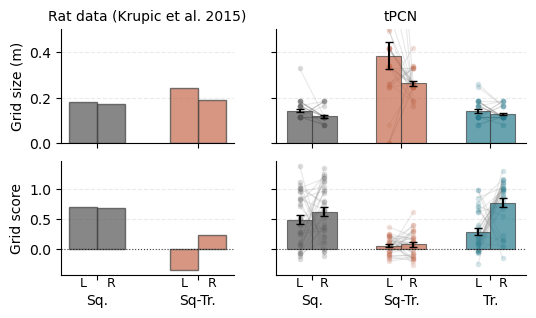

In [27]:
def plot_krupic_split_half_tracked_with_rat(krupic_cell_df, krupic_summary, save=True):
    # Swapped order: Sq first, then Sq-Tr, then Tr.
    conditions = ["Sq.", "Sq-Tr. 0.4", "Tr. 0.4"]
    display_names = {
        "Sq.": "Sq.",
        "Sq-Tr. 0.4": "Sq-Tr.",
        "Tr. 0.4": "Tr.",
    }
    colors = {
        "Sq-Tr. 0.4": "#C56A4D",
        "Sq.": "#555555",
        "Tr. 0.4": "#287C8E",
    }

    # Attached R/L pairs.
    sides = ["Left", "Right"]
    width = 0.34
    pair_gap = 0.55

    fig, axes = plt.subplots(
        2, 2,
        figsize=(6.0, 3.2),
        sharey="row",
        sharex="col",
        gridspec_kw={"width_ratios": [1.1, 1.6], "wspace": 0.2, "hspace": 0.15},
    )

    # ---------- Rat data ----------
    rat_groups = [
        ("Sq.", "#555555", rat_sizes["sq right"], rat_sizes["sq left"], rat_scores["sq right"], rat_scores["sq left"]),
        ("Sq-Tr.", "#C56A4D", rat_sizes["sq2tr right"], rat_sizes["sq2tr left"], rat_scores["sq2tr right"], rat_scores["sq2tr left"]),
    ]

    rat_xticks, rat_xticklabels = [], []

    for gi, (label, color, size_r, size_l, score_r, score_l) in enumerate(rat_groups):
        center = gi * (2 * width + pair_gap)
        xpos_l = center - width / 2
        xpos_r = center + width / 2

        rat_xticks.append(center)
        rat_xticklabels.append(label)

        axes[0, 0].bar([xpos_r, xpos_l], [size_r, size_l], width=width, color=color, alpha=0.7, edgecolor="0.25")
        axes[1, 0].bar([xpos_r, xpos_l], [score_r, score_l], width=width, color=color, alpha=0.7, edgecolor="0.25")

        # small R/L labels over each attached pair
        # for ax in axes[:, 0]:
        axes[1, 0].text(
            xpos_r, -0.01, "R",
            transform=axes[1, 0].get_xaxis_transform(),
            ha="center", va="top", fontsize=9,
            clip_on=False,
        )
        axes[1, 0].text(
            xpos_l, -0.01, "L",
            transform=axes[1, 0].get_xaxis_transform(),
            ha="center", va="top", fontsize=9,
            clip_on=False,
        )

    for ax, ylabel in zip(axes[:, 0], ["Grid size (m)", "Grid score"]):
        ax.set_xticks(rat_xticks)
        ax.set_xticklabels(rat_xticklabels, fontsize=10)
        ax.set_ylabel(ylabel)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.set_axisbelow(True)

    axes[1, 0].axhline(0, color="black", lw=0.8, ls=":", alpha=0.7)
    axes[0, 0].set_title("Rat data (Krupic et al. 2015)", fontsize=10)

    # ---------- Model data ----------
    specs = [
        ("grid_size_m", "grid_size_mean", "grid_size_sem", "Grid size (m)"),
        ("grid_score", "grid_score_mean", "grid_score_sem", "Grid score"),
    ]

    model_xticks, model_xticklabels = [], []

    for ci, cond in enumerate(conditions):
        center = ci * (2 * width + pair_gap)
        xpos = {"Right": center - width / 2, "Left": center + width / 2}

        model_xticks.append(center)
        model_xticklabels.append(display_names[cond])

        sub = krupic_cell_df[krupic_cell_df["condition"] == cond]

        for ax, (cell_col, mean_col, sem_col, ylabel) in zip(axes[:, 1], specs):
            wide = sub.pivot(index="cell", columns="side", values=cell_col)

            for _, row in wide.dropna(subset=sides).iterrows():
                ax.plot(
                    [xpos["Left"], xpos["Right"]],  
                    [row["Left"], row["Right"]],
                    color="0.55",
                    lw=0.8,
                    alpha=0.2,
                    zorder=1,
                    marker="o",
                    markerfacecolor=colors[cond],
                    markeredgewidth=0,
                    markersize=4,
                )

            for side in sides:
                srow = krupic_summary[
                    (krupic_summary["condition"] == cond)
                    & (krupic_summary["side"] == side)
                ]

                ax.bar(
                    xpos[side],
                    float(srow[mean_col].iloc[0]),
                    yerr=float(srow[sem_col].iloc[0]),
                    width=width,
                    color=colors[cond],
                    alpha=0.7,
                    edgecolor="0.25",
                    linewidth=0.8,
                    capsize=3,
                    zorder=2,
                )


        axes[1, 1].text(
            xpos["Right"], -0.01, "L",
            transform=axes[1, 1].get_xaxis_transform(),
            ha="center", va="top", fontsize=9,
            clip_on=False,
        )
        axes[1, 1].text(
            xpos["Left"], -0.01, "R",
            transform=axes[1, 1].get_xaxis_transform(),
            ha="center", va="top", fontsize=9,
            clip_on=False,
        )

    for ax in axes[:, 1]:
        ax.set_xticks(model_xticks)
        ax.set_xticklabels(model_xticklabels, fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.set_axisbelow(True)

    for ax in axes[0]:
        ax.set_ylim(0, 0.5)
        ax.set_xlabel("")

    for ax in axes[1]:
        ax.tick_params(axis="x", pad=10)

    axes[1, 1].axhline(0, color="black", lw=0.8, ls=":", alpha=0.7)
    axes[0, 1].set_title("tPCN", fontsize=10)

    if save:
        fig.savefig(FIG_DIR / "krupic_split_half_top04_tracked_with_rat.pdf", bbox_inches="tight")
        fig.savefig(FIG_DIR / "krupic_split_half_top04_tracked_with_rat.png", dpi=300, bbox_inches="tight")

    return fig, axes


plot_krupic_split_half_tracked_with_rat(krupic_cell_df, krupic_summary, save=False)

In [28]:
def plot_krupic_model_panel(
    krupic_cell_df,
    krupic_summary,
    title="tPCN",
    save_name=None,
):
    conditions = ["Sq.", "Sq-Tr. 0.4", "Tr. 0.4"]
    display_names = {
        "Sq.": "Sq.",
        "Sq-Tr. 0.4": "Sq-Tr.",
        "Tr. 0.4": "Tr.",
    }
    colors = {
        "Sq.": "#555555",
        "Sq-Tr. 0.4": "#C56A4D",
        "Tr. 0.4": "#287C8E",
    }

    sides = ["Left", "Right"]
    width = 0.34
    pair_gap = 0.55

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(3.55, 3.2),
        sharex=True,
        gridspec_kw={"hspace": 0.15},
    )

    specs = [
        ("grid_size_m", "grid_size_mean", "grid_size_sem", "Grid size (m)"),
        ("grid_score", "grid_score_mean", "grid_score_sem", "Grid score"),
    ]

    xticks = []
    xticklabels = []

    for ci, condition in enumerate(conditions):
        center = ci * (2 * width + pair_gap)
        xpos = {
            "Right": center - width / 2,
            "Left": center + width / 2,
        }

        xticks.append(center)
        xticklabels.append(display_names[condition])

        cell_sub = krupic_cell_df[
            krupic_cell_df["condition"] == condition
        ]

        for ax, (cell_col, mean_col, sem_col, ylabel) in zip(axes, specs):
            wide = cell_sub.pivot(
                index="cell",
                columns="side",
                values=cell_col,
            )

            for _, row in wide.dropna(subset=sides).iterrows():
                ax.plot(
                    [xpos["Left"], xpos["Right"]],
                    [row["Left"], row["Right"]],
                    color="0.55",
                    lw=0.8,
                    alpha=0.2,
                    marker="o",
                    markerfacecolor=colors[condition],
                    markeredgewidth=0,
                    markersize=4,
                    zorder=1,
                )

            for side in sides:
                summary_row = krupic_summary[
                    (krupic_summary["condition"] == condition)
                    & (krupic_summary["side"] == side)
                ]

                ax.bar(
                    xpos[side],
                    float(summary_row[mean_col].iloc[0]),
                    yerr=float(summary_row[sem_col].iloc[0]),
                    width=width,
                    color=colors[condition],
                    alpha=0.7,
                    edgecolor="0.25",
                    linewidth=0.8,
                    capsize=3,
                    zorder=2,
                )

        axes[1].text(
            xpos["Right"],
            -0.01,
            "R",
            transform=axes[1].get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            clip_on=False,
        )
        axes[1].text(
            xpos["Left"],
            -0.01,
            "L",
            transform=axes[1].get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            clip_on=False,
        )

    for ax, (_, _, _, ylabel) in zip(axes, specs):
        ax.set_ylabel(ylabel)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.set_axisbelow(True)

    axes[0].set_ylim(0, 0.5)
    axes[0].set_title(title, fontsize=10)
    axes[1].tick_params(axis="x", pad=10)
    axes[1].axhline(0, color="black", lw=0.8, ls=":", alpha=0.7)

    fig.tight_layout()

    if save_name is not None:
        fig.savefig(
            FIG_DIR / f"{save_name}.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIG_DIR / f"{save_name}.png",
            dpi=300,
            bbox_inches="tight",
        )

    return fig, axes

C:\Users\User\AppData\Local\Temp\ipykernel_37364\3333065617.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


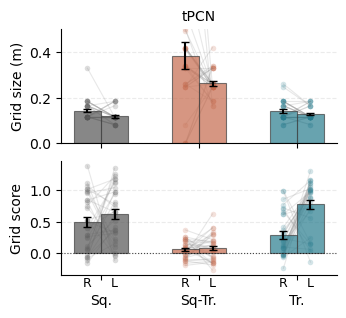

In [29]:
fig, axes = plot_krupic_model_panel(
    krupic_cell_df,
    krupic_summary,
    # title="tPCN, seed 0",
    save_name="krupic_model_seed_2",
)
plt.show()

,condition,threshold,fraction_mean,fraction_sd,n_runs
0,Sq-Tr. 0.4,0.8,0.000651,0.001128,3
1,Sq.,0.8,0.085612,0.006502,3
2,Tr. 0.4,0.8,0.045898,0.006099,3


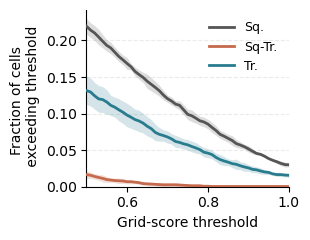

In [43]:
# Population prevalence across independent training runs.
GRID_SCORE_THRESHOLDS = np.linspace(0.5, 1.0, 51)
KRUPIC_RUNS_BY_SEED = {
    0: {
        "Sq.": "Apr-10-2025-16-13-23",
        "Sq-Tr. 0.4": "May-28-2026-22-49-13",
        "Tr. 0.4": "May-28-2026-00-25-00",
    },
    1: {
        "Sq.": "Aug-31-2026-20-46-42",
        "Sq-Tr. 0.4": "Aug-31-2026-21-55-49",
        "Tr. 0.4": "Aug-31-2026-19-37-03",
    },
    2: {
        "Sq.": "Aug-31-2026-23-40-21",
        "Sq-Tr. 0.4": "Sep-01-2026-00-49-25",
        "Tr. 0.4": "Aug-31-2026-22-30-47",
    },
}

condition_order = ["Sq.", "Sq-Tr. 0.4", "Tr. 0.4"]
display_names = {"Sq.": "Sq.", "Sq-Tr. 0.4": "Sq-Tr.", "Tr. 0.4": "Tr."}
condition_colors = {"Sq.": "#555555", "Sq-Tr. 0.4": "#C56A4D", "Tr. 0.4": "#287C8E"}

prevalence_rows = []
for seed, runs in KRUPIC_RUNS_BY_SEED.items():
    for condition, run_id in runs.items():
        scores = np.load(RESULTS_DIR / run_id / "unsrt_grid_scores.npy").reshape(-1)
        scores = scores[np.isfinite(scores)]
        for threshold in GRID_SCORE_THRESHOLDS:
            prevalence_rows.append({
                "seed": seed,
                "condition": condition,
                "run": run_id,
                "threshold": float(threshold),
                "n_cells": len(scores),
                "n_above_threshold": int(np.sum(scores > threshold)),
                "fraction_above_threshold": float(np.mean(scores > threshold)),
            })

krupic_prevalence_df = pd.DataFrame(prevalence_rows)
krupic_prevalence_summary = (
    krupic_prevalence_df
    .groupby(["condition", "threshold"], as_index=False)
    .agg(
        fraction_mean=("fraction_above_threshold", "mean"),
        fraction_sd=("fraction_above_threshold", "std"),
        n_runs=("seed", "nunique"),
    )
)

# Retain the reviewer's requested threshold as a compact numerical summary.
display(
    krupic_prevalence_summary[
        np.isclose(krupic_prevalence_summary["threshold"], 0.8)
    ].reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(3.2, 2.5))
for condition in condition_order:
    sub = (
        krupic_prevalence_summary[
            krupic_prevalence_summary["condition"] == condition
        ]
        .sort_values("threshold")
    )
    threshold = sub["threshold"].to_numpy()
    mean = sub["fraction_mean"].to_numpy()
    sd = sub["fraction_sd"].to_numpy()
    color = condition_colors[condition]

    ax.plot(
        threshold, mean, color=color, lw=2,
        label=display_names[condition], zorder=3,
    )
    ax.fill_between(
        threshold,
        np.clip(mean - sd, 0, 1),
        np.clip(mean + sd, 0, 1),
        color=color, alpha=0.2, linewidth=0, zorder=2,
    )

# ax.axvline(0.8, color="0.35", lw=0.8, ls=":", zorder=1)
ax.set_xlabel("Grid-score threshold")
ax.set_ylabel("Fraction of cells \n exceeding threshold")
ax.set_xlim(GRID_SCORE_THRESHOLDS.min(), GRID_SCORE_THRESHOLDS.max())
ax.set_ylim(bottom=0)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
fig.tight_layout()

fig.savefig(FIG_DIR / "krupic_grid_cell_prevalence_threshold_sweep.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "krupic_grid_cell_prevalence_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
# Seed-level split-half statistics for Sq., Sq.-Tr., and Tr.
N_TRACKED_CELLS = 32

seed_cell_frames = []

for seed, runs in KRUPIC_RUNS_BY_SEED.items():
    square_run = runs["Sq."]
    square_cells = top_grid_cell_indices(
        square_run,
        n_cells=N_TRACKED_CELLS,
    )

    for condition, run_id in runs.items():
        if condition in ["Sq.", "Sq-Tr. 0.4"]:
            # Track each seed's square-selected cells through transfer.
            cell_df = load_run_split_half_metrics(
                run_id,
                n_cells=N_TRACKED_CELLS,
                cell_indices=square_cells,
                selection_label="matching_square_top_32",
            )
        else:
            # The de novo trapezoid has no corresponding square population.
            cell_df = load_run_split_half_metrics(
                run_id,
                n_cells=N_TRACKED_CELLS,
                selection_label="run_top_32",
            )

        cell_df["seed"] = seed
        cell_df["condition"] = condition
        seed_cell_frames.append(cell_df)

krupic_all_seed_cell_df = pd.concat(
    seed_cell_frames,
    ignore_index=True,
)

# First average across cells within each independently trained network.
krupic_seed_half_means = (
    krupic_all_seed_cell_df
    .groupby(
        ["seed", "condition", "run", "side"],
        as_index=False,
    )
    .agg(
        grid_size_mean_m=("grid_size_m", "mean"),
        grid_score_mean=("grid_score", "mean"),
        n_cells=("cell", "nunique"),
    )
)

krupic_seed_half_means["grid_size_mean_cm"] = (
    100 * krupic_seed_half_means["grid_size_mean_m"]
)

# Then summarize the three independent networks.
krupic_across_seed_summary = (
    krupic_seed_half_means
    .groupby(["condition", "side"], as_index=False)
    .agg(
        grid_size_mean_cm=("grid_size_mean_cm", "mean"),
        grid_size_sd_cm=("grid_size_mean_cm", "std"),
        grid_score_mean=("grid_score_mean", "mean"),
        grid_score_sd=("grid_score_mean", "std"),
        n_runs=("seed", "nunique"),
    )
)

condition_order = ["Sq.", "Sq-Tr. 0.4", "Tr. 0.4"]
side_order = ["Left", "Right"]

krupic_seed_half_means["condition"] = pd.Categorical(
    krupic_seed_half_means["condition"],
    categories=condition_order,
    ordered=True,
)
krupic_seed_half_means["side"] = pd.Categorical(
    krupic_seed_half_means["side"],
    categories=side_order,
    ordered=True,
)

krupic_across_seed_summary["condition"] = pd.Categorical(
    krupic_across_seed_summary["condition"],
    categories=condition_order,
    ordered=True,
)
krupic_across_seed_summary["side"] = pd.Categorical(
    krupic_across_seed_summary["side"],
    categories=side_order,
    ordered=True,
)

krupic_seed_half_means = krupic_seed_half_means.sort_values(
    ["condition", "seed", "side"]
).reset_index(drop=True)

krupic_across_seed_summary = krupic_across_seed_summary.sort_values(
    ["condition", "side"]
).reset_index(drop=True)

display(krupic_seed_half_means.round(4))
display(krupic_across_seed_summary.round(4))

# Save the intermediate and final values used in the manuscript.
krupic_seed_half_means.to_csv(
    FIG_DIR / "krupic_seed_level_half_means.csv",
    index=False,
)
krupic_across_seed_summary.to_csv(
    FIG_DIR / "krupic_across_seed_half_summary.csv",
    index=False,
)

C:\Users\User\AppData\Local\Temp\ipykernel_37364\3741983600.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  krupic_all_seed_cell_df = pd.concat(


,seed,condition,run,side,grid_size_mean_m,grid_score_mean,n_cells,grid_size_mean_cm
0,0,Sq.,Apr-10-2025-16-13-23,Left,0.1267,0.5660,32,12.6677
1,0,Sq.,Apr-10-2025-16-13-23,Right,0.1258,0.7056,32,12.5804
2,1,Sq.,Aug-31-2026-20-46-42,Left,0.1185,0.5351,32,11.8535
3,1,Sq.,Aug-31-2026-20-46-42,Right,0.1252,0.6470,32,12.5199
4,2,Sq.,Aug-31-2026-23-40-21,Left,0.1185,0.6262,32,11.8535
5,2,Sq.,Aug-31-2026-23-40-21,Right,0.1437,0.4913,32,14.3719
6,0,Sq-Tr. 0.4,May-28-2026-22-49-13,Left,0.2594,0.0741,32,25.9443
7,0,Sq-Tr. 0.4,May-28-2026-22-49-13,Right,0.3688,-0.0195,32,36.8822
8,1,Sq-Tr. 0.4,Aug-31-2026-21-55-49,Left,0.2619,0.1294,32,26.1926
9,1,Sq-Tr. 0.4,Aug-31-2026-21-55-49,Right,0.3722,0.0266,32,37.2157


,condition,side,grid_size_mean_cm,grid_size_sd_cm,grid_score_mean,grid_score_sd,n_runs
0,Sq.,Left,12.1249,0.4701,0.5758,0.0463,3
1,Sq.,Right,13.1574,1.0522,0.6146,0.1107,3
2,Sq-Tr. 0.4,Left,26.1131,0.1463,0.0924,0.0321,3
3,Sq-Tr. 0.4,Right,37.4580,0.7278,0.0210,0.0380,3
4,Tr. 0.4,Left,13.6430,0.7527,0.7423,0.0783,3
5,Tr. 0.4,Right,14.6122,0.5370,0.3414,0.0583,3
